# Results by group complexity (evalmaxsat vs exact)

In [1]:

!pwd

/Users/wilberquito/repos/mspsp-all/mspsp-stats/notebooks/smtapi/by-complexity/maxcdcl-roundingsat


In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent.parent
print(ROOT)

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

# Set working directory to the notebook's location

pprint(DIRS)

/Users/wilberquito/repos/mspsp-all/mspsp-stats
{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/figures/smtapi')}


In [3]:
hardness_instances_csv = f"{DIRS['data']['analysis']}/mspsp_stats.csv"
df_hardness = pd.read_csv(hardness_instances_csv)
df_hardness.shape

(1142, 10)

In [4]:
df_hardness.head(2)

,family,n_activities,n_skills,n_resources,n_precedences,skill_factor,modified_resource_strength,network_complexity,network_density,mspsp_instance
0,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...
1,set-1a,22,4,10,31,0.5,0.125,1.409091,0.134199,./modules/rcpsp-instances/MSPSP/set-1a/inst_se...


In [5]:
df_hardness.columns

Index(['family', 'n_activities', 'n_skills', 'n_resources', 'n_precedences',
       'skill_factor', 'modified_resource_strength', 'network_complexity',
       'network_density', 'mspsp_instance'],
      dtype='object')

In [6]:
# Plot a distribution of the modified resource strength & agragate it by bins range

df_hardness["modified_resource_strength_bin"] = pd.cut(
    df_hardness["modified_resource_strength"], bins=5
)
df_hardness.groupby("modified_resource_strength_bin").size().reset_index(name="count")

/var/folders/pg/qxgft6y5619fnqtqh5mq_lx00000gn/T/ipykernel_82946/59486896.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_hardness.groupby("modified_resource_strength_bin").size().reset_index(name="count")


,modified_resource_strength_bin,count
0,"(0.0105, 0.0541]",566
1,"(0.0541, 0.0974]",363
2,"(0.0974, 0.141]",62
3,"(0.141, 0.184]",77
4,"(0.184, 0.227]",74


In [7]:
# Generate a list of ranges from the modified resource strength bins
bins = df_hardness["modified_resource_strength_bin"].cat.categories
bins_ranges = [bin for bin in bins]
bins_ranges

[Interval(0.0105, 0.0541, closed='right'),
 Interval(0.0541, 0.0974, closed='right'),
 Interval(0.0974, 0.141, closed='right'),
 Interval(0.141, 0.184, closed='right'),
 Interval(0.184, 0.227, closed='right')]

In [8]:
# Read all csv under the wandb directory
wandb_dir = DIRS["data"]["wandb"]

df_wandb = pd.concat(
    [
        pd.read_csv(os.path.join(wandb_dir, f))
        for f in os.listdir(wandb_dir)
        if f.endswith(".csv")
    ],
    ignore_index=True,
)
df_wandb.shape

(27408, 22)

In [9]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like'],
      dtype='object')

In [10]:
# Pick just solvers of interest
exclude_solvers = ["maxcdcl", "roundingsat"]
exclude_solvers = ["exactpb", "evalmaxsat"]
df_wandb = df_wandb[~df_wandb["solver"].isin(exclude_solvers)]

df_wandb.shape

(13704, 22)

In [11]:
df_wandb["inline_config"].value_counts().sort_index()

inline_config
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0                1142
f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0                1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=1__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=0,i3=1,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=0,i2=1,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=1,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0    1142
Name: count, dtype: int64

In [12]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(lambda x: np.log10(x))
    return df


def add_bins_by_modified_resource_strength(
    df: pd.DataFrame, bins_ranges: list
) -> pd.DataFrame:
    df["modified_resource_strength_bin"] = pd.cut(
        df["modified_resource_strength"], bins=bins_ranges
    )
    return df


df_wandb = add_implied_column(df_wandb, check=True)
df_wandb = add_logarithmic_time(df_wandb)

# Merge with hardness dataframe to get the modified resource strength bins
df_wandb = df_wandb.merge(
    df_hardness[["mspsp_instance", "modified_resource_strength"]],
    on="mspsp_instance",
)
bins = [
    bins_ranges[0],
    bins_ranges[1],
    pd.Interval(left=bins_ranges[2].left, right=bins_ranges[-1].right, closed="right"),
]
bins = [b for b in bins_ranges]
edges = [bins[0].left] + [b.right for b in bins]
df_wandb = add_bins_by_modified_resource_strength(df_wandb, bins_ranges=edges)

In [13]:
df_wandb["implied_bitmask"].value_counts()

implied_bitmask
0001    2284
0010    2284
0000    2284
1100    2284
1000    2284
0100    2284
Name: count, dtype: int64

In [14]:
df_wandb["modified_resource_strength_bin"].value_counts()

modified_resource_strength_bin
(0.0105, 0.0541]    6792
(0.0541, 0.0974]    4356
(0.141, 0.184]       924
(0.184, 0.227]       864
(0.0974, 0.141]      744
Name: count, dtype: int64

In [15]:
df_wandb["solver.real_time"].describe()

count    13704.000000
mean       340.760108
std        284.751696
min          0.030000
25%          2.900000
50%        600.000000
75%        600.000000
max        600.050000
Name: solver.real_time, dtype: float64

In [16]:
df_wandb["solver.log_real_time"].describe()

count    13704.000000
mean         1.730396
std          1.351405
min         -1.522879
25%          0.462398
50%          2.778151
75%          2.778151
max          2.778187
Name: solver.log_real_time, dtype: float64

In [17]:
df_wandb["modified_resource_strength_bin"].value_counts()

modified_resource_strength_bin
(0.0105, 0.0541]    6792
(0.0541, 0.0974]    4356
(0.141, 0.184]       924
(0.184, 0.227]       864
(0.0974, 0.141]      744
Name: count, dtype: int64

In [18]:
df_wandb["solver"].value_counts()

solver
maxcdcl        6852
roundingsat    6852
Name: count, dtype: int64

In [19]:
# Rename exactpb to exact
df_wandb["solver"] = df_wandb["solver"].replace({"exactpb": "exact"})
df_wandb["solver"].value_counts()

solver
maxcdcl        6852
roundingsat    6852
Name: count, dtype: int64

In [20]:
bitmask_to_exclude = ["0001"]
df_wandb = df_wandb[~df_wandb["implied_bitmask"].isin(bitmask_to_exclude)]
df_wandb["implied_bitmask"].value_counts()

implied_bitmask
0010    2284
0000    2284
1100    2284
1000    2284
0100    2284
Name: count, dtype: int64

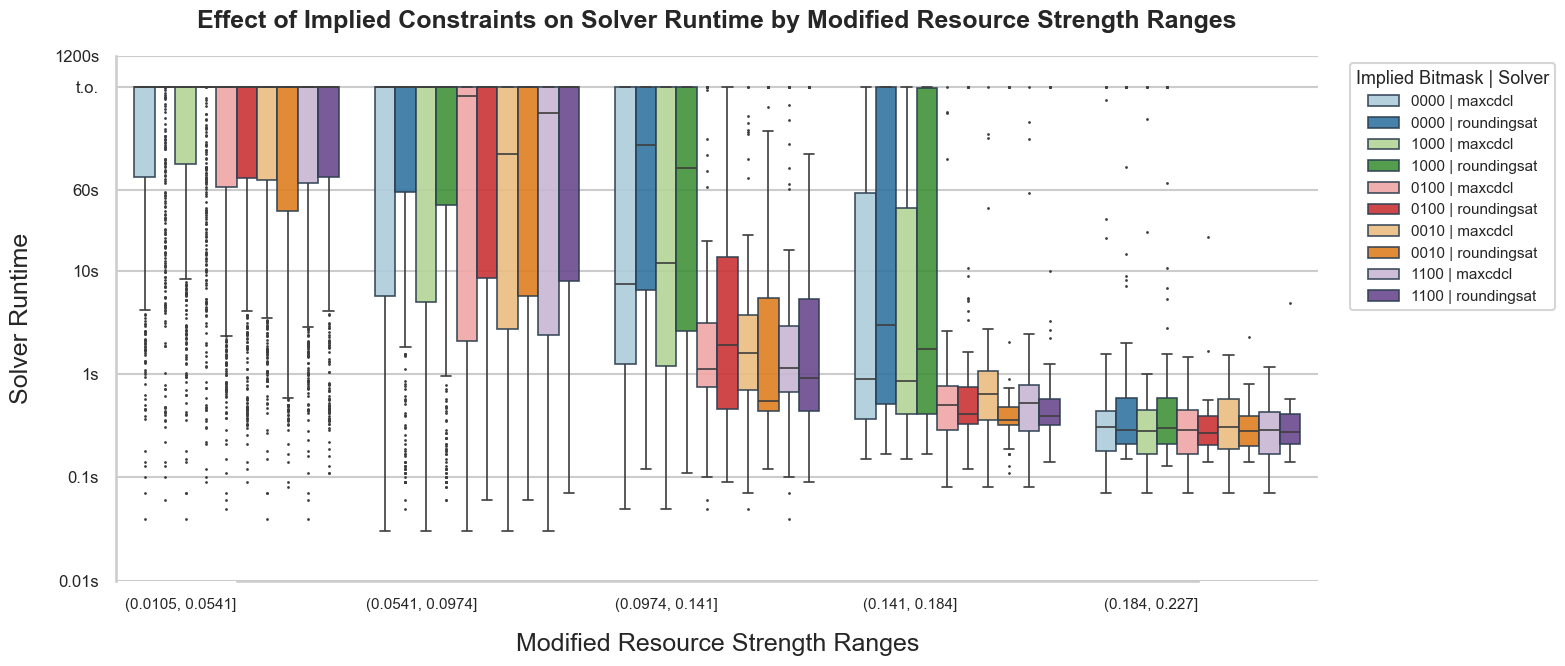

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")


df = df_wandb.copy()

df["implied_bitmask_str"] = df["implied_bitmask"].astype(str)


def safe_binary_sort(val):
    try:
        # Tries to parse binary (e.g., "010" -> 2)
        return int(float(val)) if "." in val else int(val, 2)
    except ValueError:
        return 999  # Put unparseable items at the end


implied_order = [
    "0000",
    "1000",
    "0100",
    "0010",
    "1100",
    # "0001",
]

solver_order = df["solver"].unique().tolist()

# Combine implied + formalism
df["group"] = df["implied_bitmask_str"] + " | " + df["solver"]

group_order = [f"{imp} | {form}" for imp in implied_order for form in solver_order]

# Increased width to 16 to handle the dense grouping per bin
plt.figure(figsize=(16, 7))

# Add padding and label for better aesthetics
ax = sns.boxplot(
    data=df,
    x="modified_resource_strength_bin",
    y="solver.log_real_time",
    hue="group",
    hue_order=group_order,
    linewidth=1.2,
    fliersize=1,
    width=0.85,  # Slightly wider to utilize space
    boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
)

timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

ymin, ymax = ax.get_ylim()
ymax = max(ymax, timeout_log + 0.2)  # Ensure 600s is visible
ax.set_ylim(ymin, ymax)

ticks, labels = [], []
for t in human_times:
    log_t = np.log10(t)
    ticks.append(log_t)
    labels.append(f"{t}s" if t != 600 else "t.o.")

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=12)

# Labels and Clean X-Axis
ax.set_xlabel("Modified Resource Strength Ranges", labelpad=15)
ax.set_ylabel("Solver Runtime", labelpad=15)
ax.set_title(
    "Effect of Implied Constraints on Solver Runtime by Modified Resource Strength Ranges",
    pad=20,
    weight="bold",
)
plt.xticks(rotation=0, ha="right", fontsize=11)

sns.despine(trim=True)

plt.legend(
    title="Implied Bitmask | Solver",
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=11,
)

plt.tight_layout()

solvers_vs = " vs. ".join(df["solver"].unique().tolist())

plt.savefig(
    os.path.join(
        DIRS["figures"],
        "head-to-head",
        f"solver_runtime_by_mrs_bin_and_implied_constraints_({solvers_vs}).png",
    ),
    dpi=300,
    transparent=True,
)

plt.show()